In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score

In [ ]:
data=pd.read_csv('/content/student_career_success_dataset.csv')

In [ ]:
data.shape

(50000, 29)

In [ ]:
data.head()

,Student_ID,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,...,Teamwork,Problem_Solving,English_Proficiency,Interview_Score,Employability_Score,Placement_Status,Company_Tier,Career_Field,Placement_Mode,Starting_Salary_USD
0,ST000001,22,Male,Sophomore,Computer Science,86,21,3.28,Good,9,...,7,8,Advanced,72,231.70,Placed,Tier 1,Backend Developer,Campus Placement,72082
1,ST000002,20,Female,Freshman,Computer Science,64,18,2.53,Poor,6,...,6,5,Basic,59,157.45,Not Placed,No Company,Not Placed,Not Applicable,0
2,ST000003,23,Male,Senior,Information Technology,75,19,2.83,Average,8,...,8,7,Advanced,76,203.45,Placed,Tier 1,IT Support Engineer,Campus Placement,94898
3,ST000004,23,Female,Senior,Information Technology,80,19,2.80,Average,5,...,6,6,Intermediate,67,171.50,Not Placed,No Company,Not Placed,Not Applicable,0
4,ST000005,23,Female,Senior,Software Engineering,73,19,2.93,Average,9,...,8,9,Advanced,82,225.45,Placed,Tier 1,Software Engineer,Internship Conversion,85256


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   University_Year        50000 non-null  object 
 4   Major                  50000 non-null  object 
 5   Attendance_Percentage  50000 non-null  int64  
 6   Study_Hours_Per_Week   50000 non-null  int64  
 7   CGPA                   50000 non-null  float64
 8   Academic_Performance   50000 non-null  object 
 9   Programming_Skill      50000 non-null  int64  
 10  Projects_Completed     50000 non-null  int64  
 11  Certifications         50000 non-null  int64  
 12  Hackathons             50000 non-null  int64  
 13  GitHub_Profile         50000 non-null  object 
 14  Internships            50000 non-null  int64  
 15  Le

In [ ]:
# Company_Tier, Career_Field ,Placement_Mode, Starting_Salary_USD,Employability_Score -----------> data leakage

In [ ]:
data['Gender'].unique() #  هنظبط ال other دي --label

array(['Male', 'Female', 'Other'], dtype=object)

In [ ]:
data['University_Year'].unique() # mapping

array(['Sophomore', 'Freshman', 'Senior', 'Junior'], dtype=object)

In [ ]:
data['Major'].unique() #one hot encode

array(['Computer Science', 'Information Technology',
       'Software Engineering', 'Artificial Intelligence',
       'Business Analytics', 'Data Science', 'Cybersecurity',
       'Electrical Engineering'], dtype=object)

In [ ]:
data['Academic_Performance'].unique() #mapping

array(['Good', 'Poor', 'Average', 'Excellent'], dtype=object)

In [ ]:
data['GitHub_Profile'].unique() # label

array(['Yes', 'No'], dtype=object)

In [ ]:
data['Leadership_Experience'].unique() #label

array(['No', 'Yes'], dtype=object)

In [ ]:
data['LinkedIn_Profile'].unique() #label

array(['No', 'Yes'], dtype=object)

In [ ]:
data['English_Proficiency'].unique() # mapping

array(['Advanced', 'Basic', 'Intermediate'], dtype=object)

In [ ]:
data.isnull().sum().sum()

np.int64(0)

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.describe()

,Age,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Programming_Skill,Projects_Completed,Certifications,Hackathons,Internships,Resume_Score,Communication_Skills,Teamwork,Problem_Solving,Interview_Score,Employability_Score,Starting_Salary_USD
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,21.262900,81.409640,21.52816,3.106043,7.137160,8.620560,1.715660,3.093940,4.048880,96.045740,8.435780,7.006200,7.175060,77.515400,213.991394,68988.167480
std,2.041163,9.709519,6.97481,0.290351,1.507194,2.505408,1.368301,1.660774,1.005719,7.331565,1.387543,1.606802,1.674428,12.579382,26.824224,38480.607679
min,18.000000,50.000000,5.00000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,44.000000,3.000000,2.000000,1.000000,17.000000,82.300000,0.000000
25%,20.000000,75.000000,17.00000,2.910000,6.000000,7.000000,1.000000,2.000000,3.000000,95.000000,7.000000,6.000000,6.000000,70.000000,197.350000,65229.250000
50%,21.000000,82.000000,21.00000,3.110000,7.000000,9.000000,2.000000,3.000000,4.000000,100.000000,9.000000,7.000000,7.000000,78.000000,217.250000,83044.500000
75%,22.000000,88.000000,26.00000,3.310000,8.000000,10.000000,3.000000,4.000000,5.000000,100.000000,10.000000,8.000000,8.000000,87.000000,233.600000,96486.250000
max,30.000000,100.000000,45.00000,4.000000,10.000000,15.000000,8.000000,10.000000,5.000000,100.000000,10.000000,10.000000,10.000000,100.000000,279.050000,110000.000000


# EDA

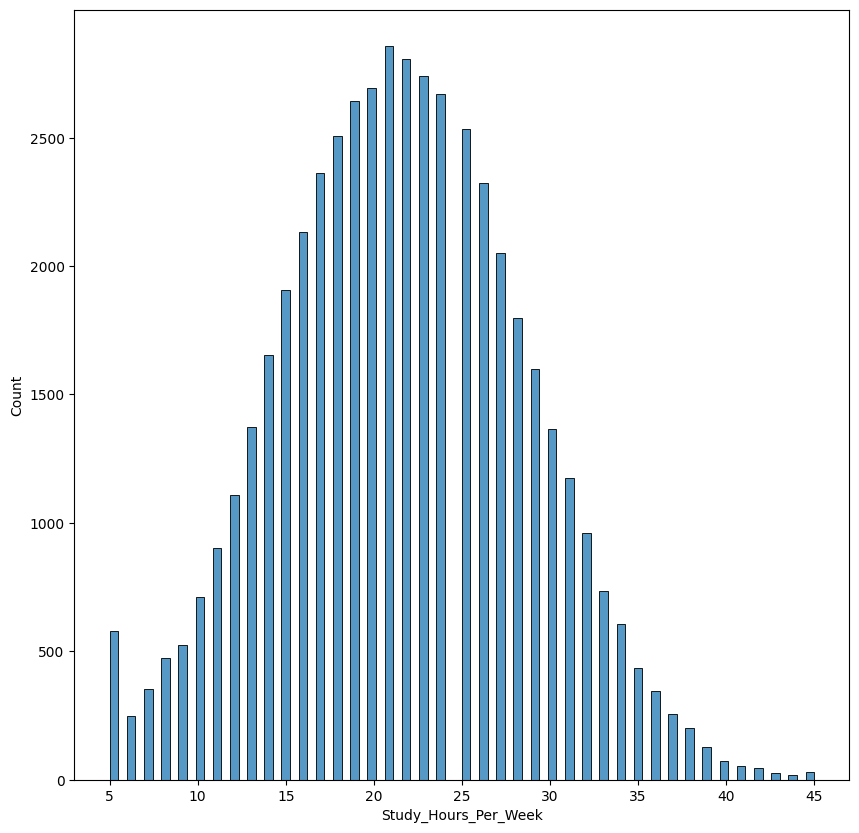

In [ ]:
plt.figure(figsize=(10,10))
sns.histplot(data['Study_Hours_Per_Week'])
plt.show()

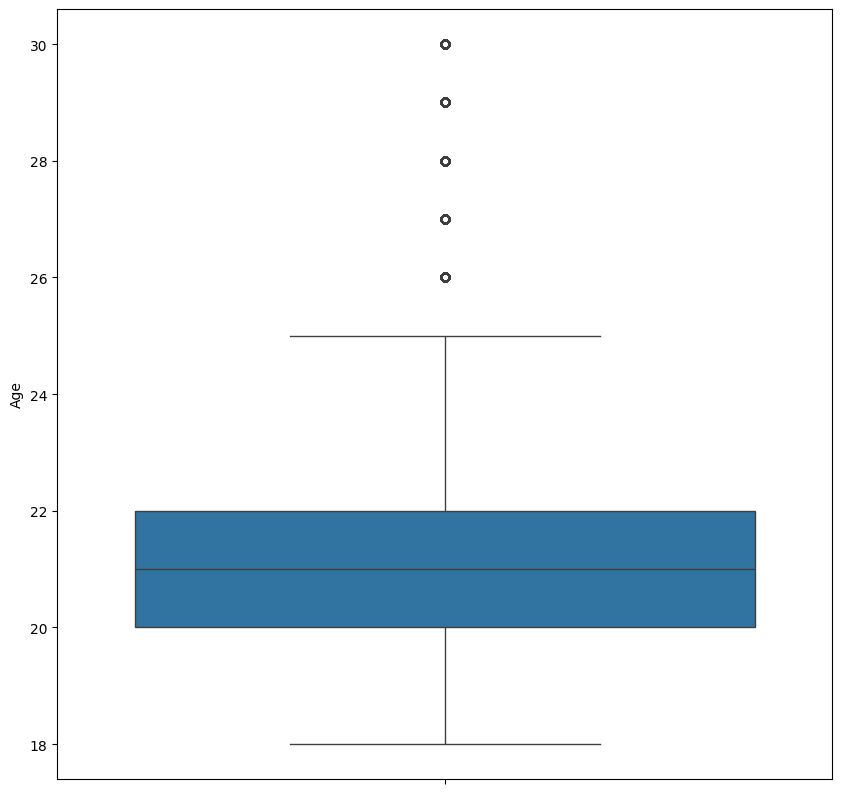

In [ ]:
plt.figure(figsize=(10,10))
sns.boxplot(data=data, y='Age')
plt.show()

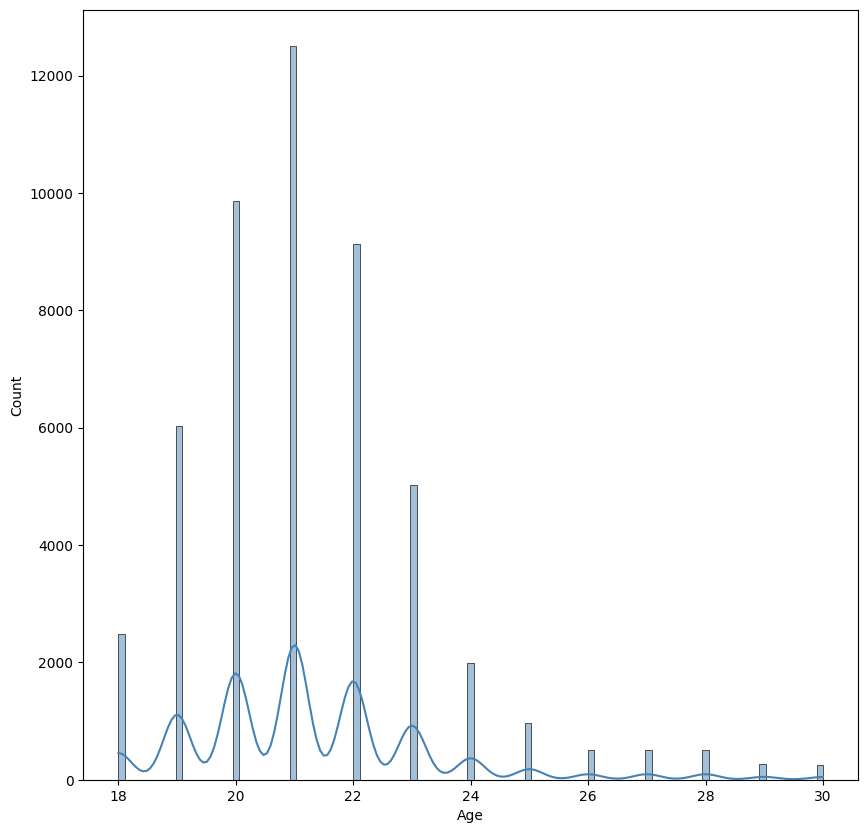

In [ ]:
plt.figure(figsize=(10,10))
sns.histplot(data=data, x='Age', kde=True, color='steelblue')
plt.show()

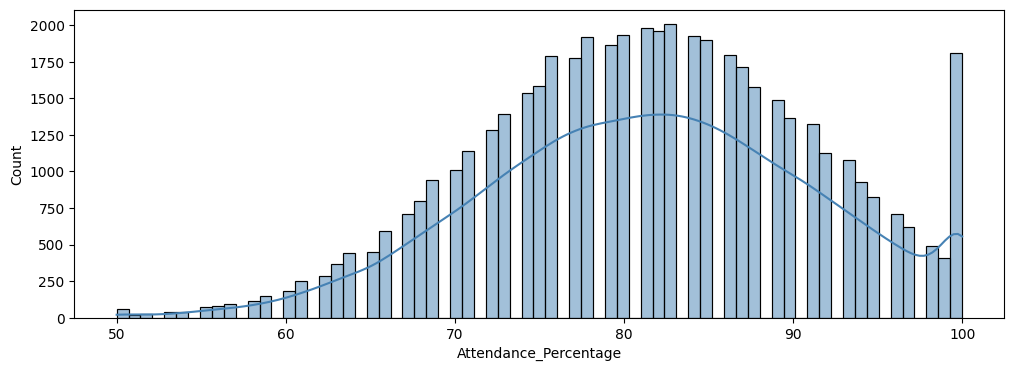

In [ ]:
plt.figure( figsize=(12,4))
sns.histplot(data=data, x='Attendance_Percentage', kde=True, color='steelblue')
plt.show()

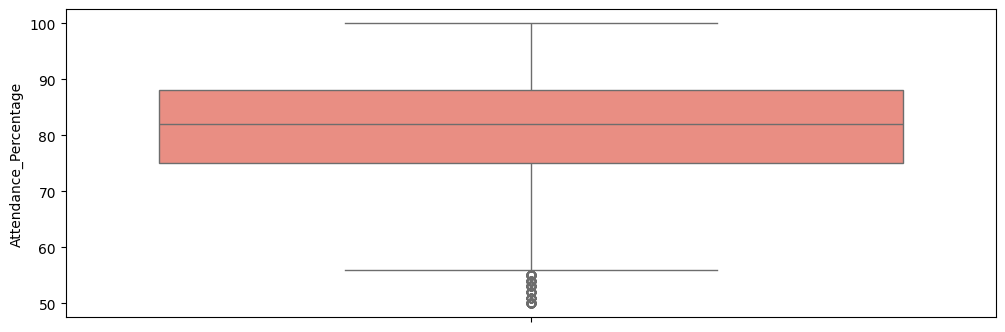

In [ ]:
plt.figure( figsize=(12,4))
sns.boxplot(data=data, y='Attendance_Percentage', color='salmon')
plt.show()

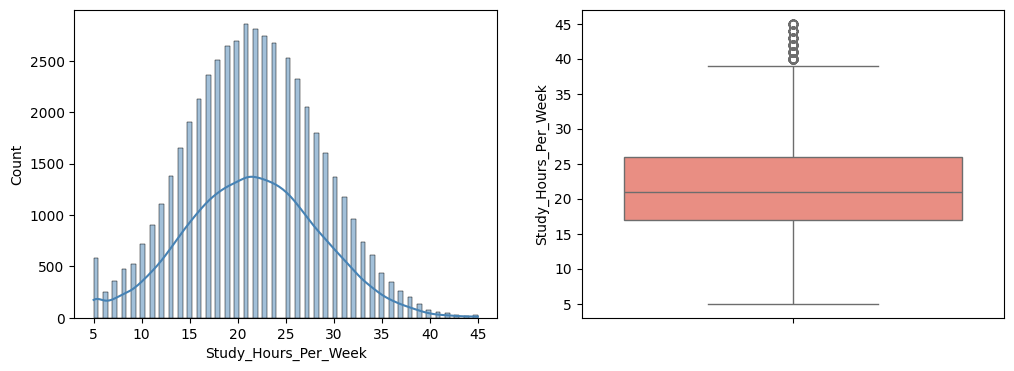

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(data=data, x='Study_Hours_Per_Week', kde=True, ax=ax[0], color='steelblue')
sns.boxplot(data=data, y='Study_Hours_Per_Week', ax=ax[1], color='salmon')
plt.show()

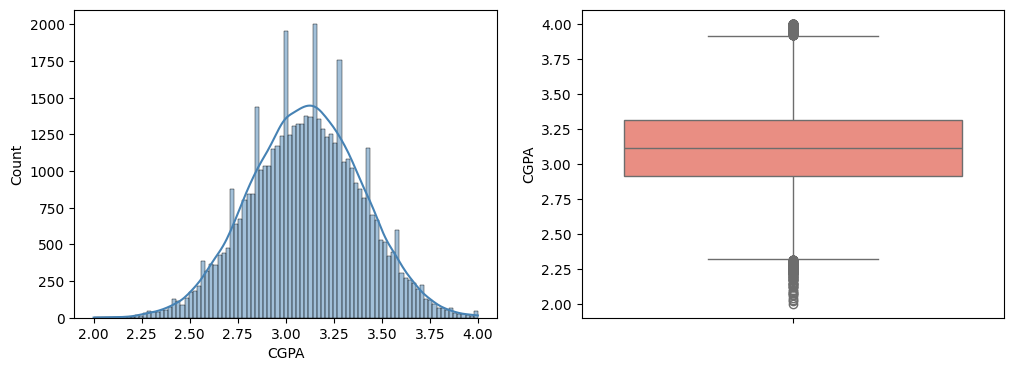

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(data=data, x='CGPA', kde=True, ax=ax[0], color='steelblue')
sns.boxplot(data=data, y='CGPA', ax=ax[1], color='salmon')
plt.show() #--------->outlier

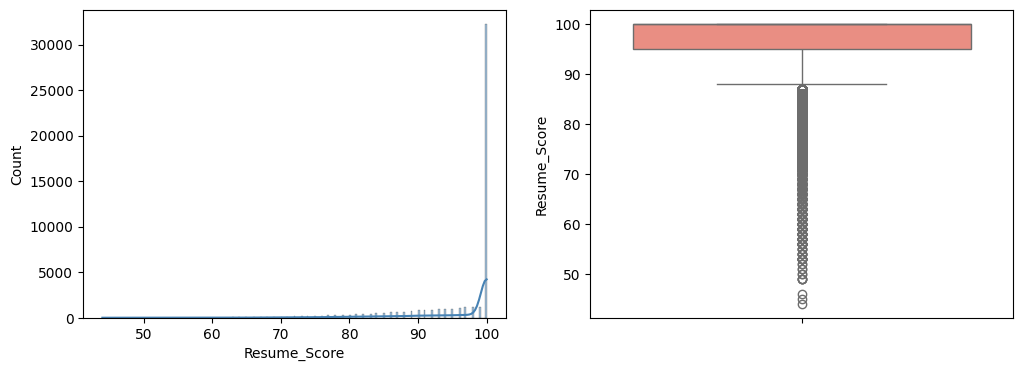

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(data=data, x='Resume_Score', kde=True, ax=ax[0], color='steelblue')
sns.boxplot(data=data, y='Resume_Score', ax=ax[1], color='salmon')
plt.show()

/tmp/ipykernel_3681/764723900.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Gender', palette='viridis')


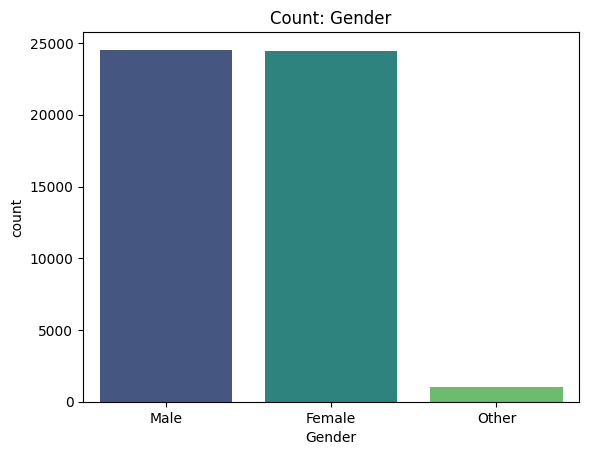

In [ ]:
# Cell - Gender
sns.countplot(data=data, x='Gender', palette='viridis')
plt.title('Count: Gender')
plt.show()

/tmp/ipykernel_3681/3758226638.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='University_Year', palette='viridis')


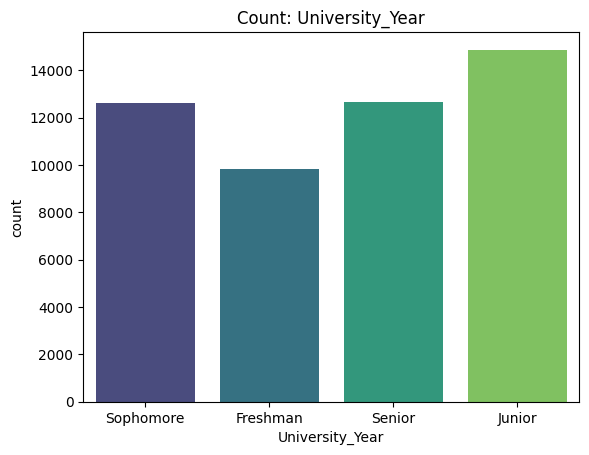

In [ ]:
sns.countplot(data=data, x='University_Year', palette='viridis')
plt.title('Count: University_Year')
plt.show()

/tmp/ipykernel_3681/3913619919.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Placement_Status', y='Interview_Score', palette='viridis')


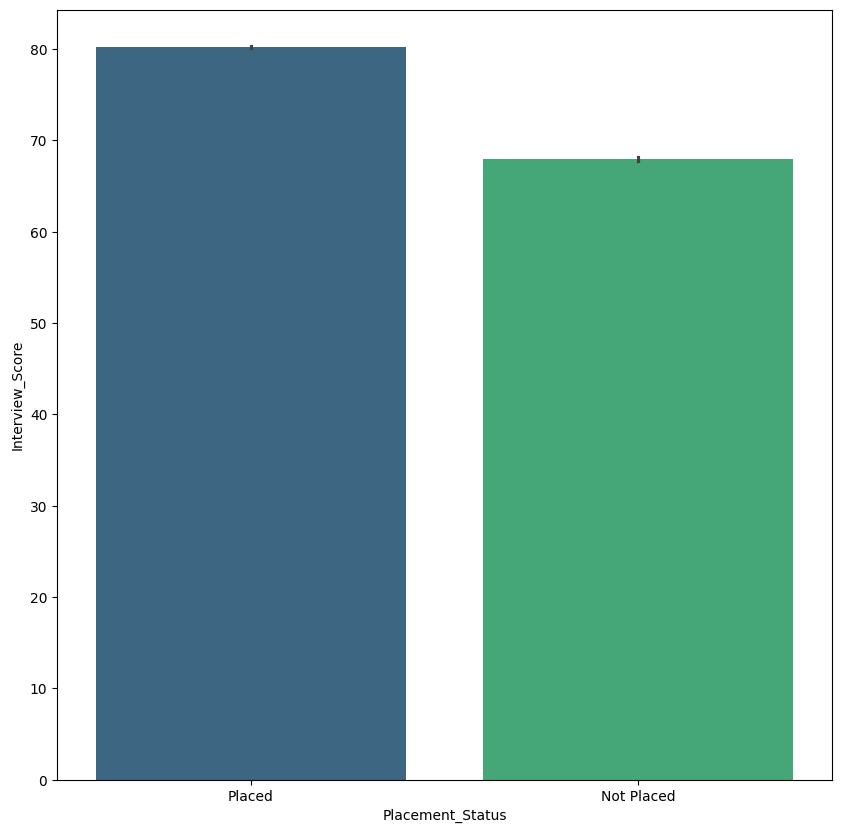

In [ ]:
plt.figure(figsize=(10,10))
sns.barplot(data=data, x='Placement_Status', y='Interview_Score', palette='viridis')
plt.show()


# PREPROCESSING

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   University_Year        50000 non-null  object 
 4   Major                  50000 non-null  object 
 5   Attendance_Percentage  50000 non-null  int64  
 6   Study_Hours_Per_Week   50000 non-null  int64  
 7   CGPA                   50000 non-null  float64
 8   Academic_Performance   50000 non-null  object 
 9   Programming_Skill      50000 non-null  int64  
 10  Projects_Completed     50000 non-null  int64  
 11  Certifications         50000 non-null  int64  
 12  Hackathons             50000 non-null  int64  
 13  GitHub_Profile         50000 non-null  object 
 14  Internships            50000 non-null  int64  
 15  Le

In [ ]:
data.drop(['Company_Tier', 'Career_Field', 'Placement_Mode', 'Starting_Salary_USD', 'Employability_Score','Student_ID'],axis=1, inplace=True)

In [ ]:
X=data.drop('Placement_Status', axis=1)
Y=data['Placement_Status']
X.shape, Y.shape

((50000, 22), (50000,))

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42,stratify=Y)

In [ ]:
X_train['Gender'] = X_train['Gender'].replace('Other',X_train['Gender'].mode()[0])
X_test['Gender'] = X_test['Gender'].replace('Other', X_train['Gender'].mode()[0])

In [ ]:
X_train['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [ ]:
le = LabelEncoder()
X_train['Gender'] = le.fit_transform(X_train['Gender'])
X_test['Gender'] = le.transform(X_test['Gender'])

In [ ]:
X_train['GitHub_Profile'] = le.fit_transform(X_train['GitHub_Profile'])
X_test['GitHub_Profile'] = le.transform(X_test['GitHub_Profile'])
X_train['LinkedIn_Profile'] = le.fit_transform(X_train['LinkedIn_Profile'])
X_test['LinkedIn_Profile'] = le.transform(X_test['LinkedIn_Profile'])

In [ ]:
X_train['Leadership_Experience'] = le.fit_transform(X_train['Leadership_Experience'])
X_test['Leadership_Experience'] = le.transform(X_test['Leadership_Experience'])

In [ ]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
major_train_encoded = ohe.fit_transform(X_train[['Major']])
major_test_encoded = ohe.transform(X_test[['Major']])
major_cols = ohe.get_feature_names_out(['Major'])
major_train_df = pd.DataFrame(major_train_encoded, columns=major_cols, index=X_train.index)
major_test_df = pd.DataFrame(major_test_encoded, columns=major_cols, index=X_test.index)
X_train = pd.concat([X_train.drop('Major', axis=1), major_train_df], axis=1)
X_test = pd.concat([X_test.drop('Major', axis=1), major_test_df], axis=1)
print(X_train.shape, X_test.shape)

(40000, 28) (10000, 28)


In [ ]:
# University_Year: Freshman < Sophomore < Junior < Senior
year_map = {'Freshman': 0, 'Sophomore': 1, 'Junior': 2, 'Senior': 3}
X_train['University_Year'] = X_train['University_Year'].map(year_map)
X_test['University_Year'] = X_test['University_Year'].map(year_map)

# Academic_Performance: Poor < Average < Good < Excellent
academic_map = {'Poor': 0, 'Average': 1, 'Good': 2, 'Excellent': 3}
X_train['Academic_Performance'] = X_train['Academic_Performance'].map(academic_map)
X_test['Academic_Performance'] = X_test['Academic_Performance'].map(academic_map)

# English_Proficiency: Basic < Intermediate < Advanced
english_map = {'Basic': 0, 'Intermediate': 1, 'Advanced': 2}
X_train['English_Proficiency'] = X_train['English_Proficiency'].map(english_map)
X_test['English_Proficiency'] = X_test['English_Proficiency'].map(english_map)

# تأكيد إنه مفيش NaN حصل (لو فيه قيمة متطابقتش مع الـ map)
print(X_train[['University_Year','Academic_Performance','English_Proficiency']].isnull().sum())
print(X_test[['University_Year','Academic_Performance','English_Proficiency']].isnull().sum())

University_Year         0
Academic_Performance    0
English_Proficiency     0
dtype: int64
University_Year         0
Academic_Performance    0
English_Proficiency     0
dtype: int64


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40000 entries, 999 to 18788
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           40000 non-null  int64  
 1   Gender                        40000 non-null  int64  
 2   University_Year               40000 non-null  int64  
 3   Attendance_Percentage         40000 non-null  int64  
 4   Study_Hours_Per_Week          40000 non-null  int64  
 5   CGPA                          40000 non-null  float64
 6   Academic_Performance          40000 non-null  int64  
 7   Programming_Skill             40000 non-null  int64  
 8   Projects_Completed            40000 non-null  int64  
 9   Certifications                40000 non-null  int64  
 10  Hackathons                    40000 non-null  int64  
 11  GitHub_Profile                40000 non-null  int64  
 12  Internships                   40000 non-null  int64  
 13  Lead

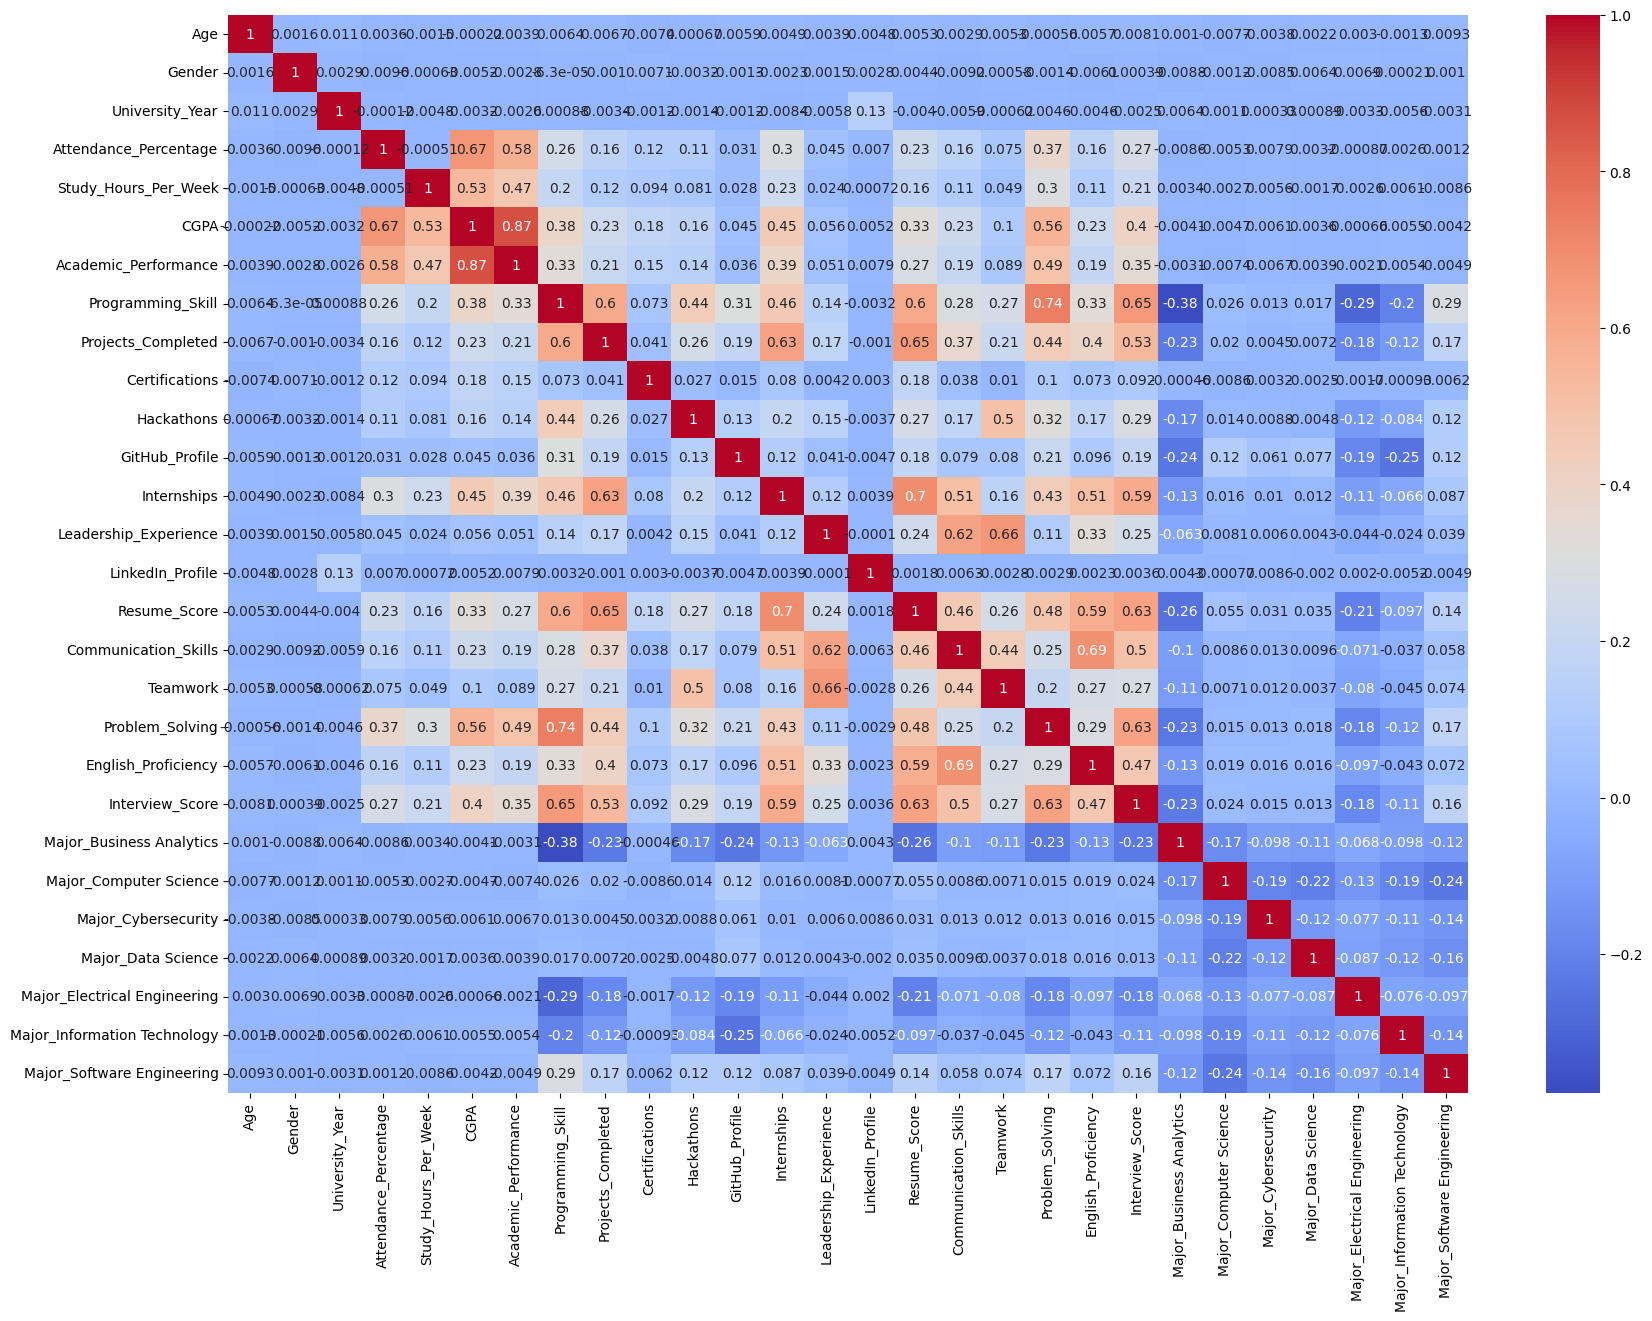

In [ ]:
plt.figure(figsize=(20,14))
sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
y_train = Y_train.map({'Placed': 1, 'Not Placed': 0})
y_test = Y_test.map({'Placed': 1, 'Not Placed': 0})

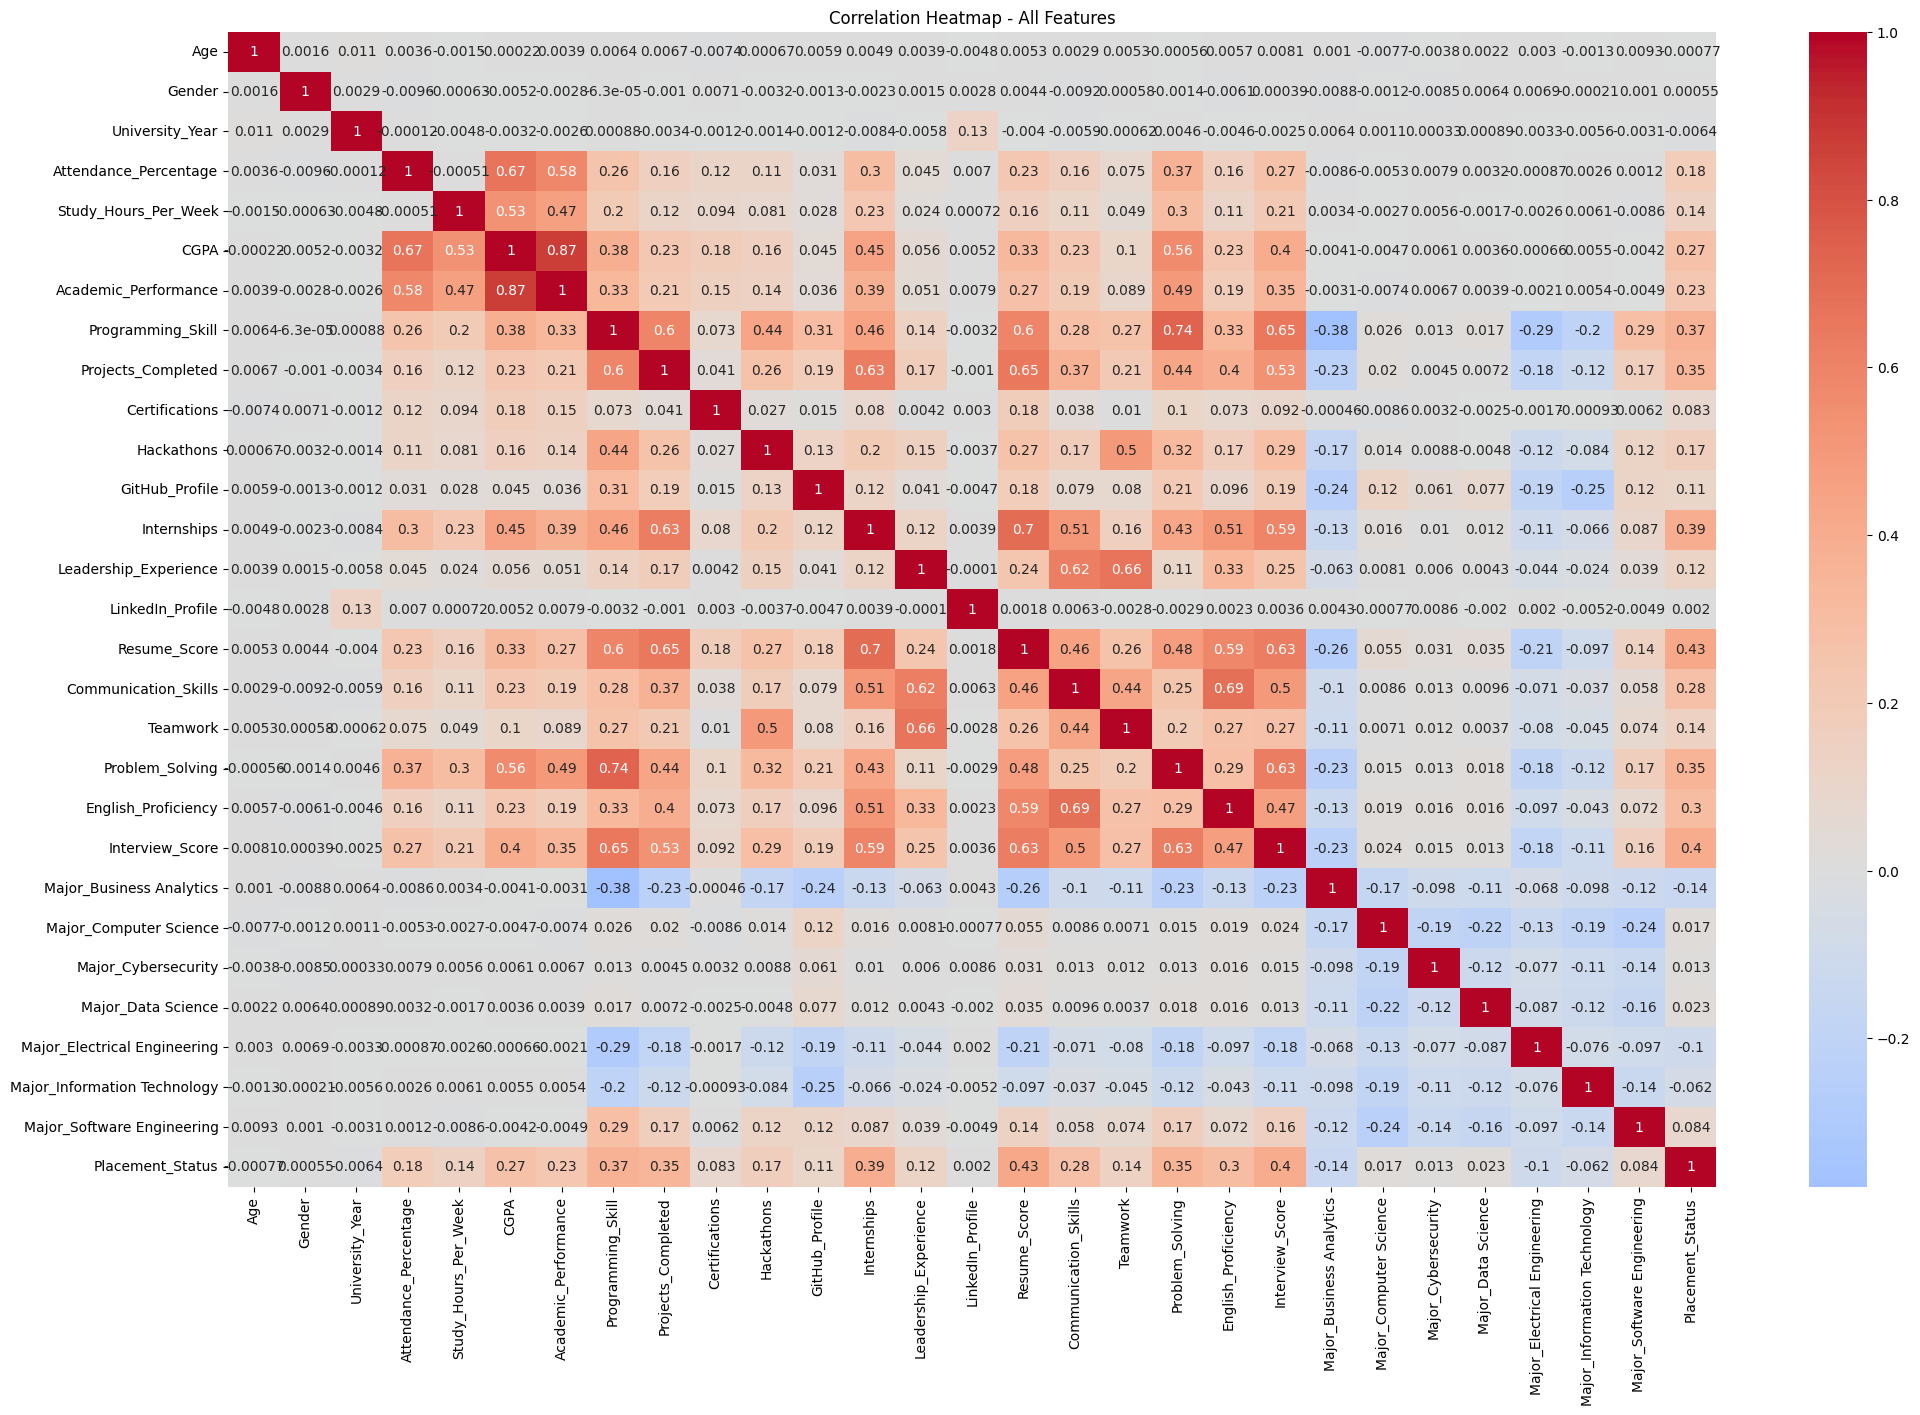

In [ ]:
# ندمج X_train مع y_train مؤقتًا للرسم بس (من غير ما نعدل الأصل)
train_full = X_train.copy()
train_full['Placement_Status'] = y_train

# نحسب الـ correlation matrix
corr = train_full.corr()

plt.figure(figsize=(24, 15))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - All Features')
plt.show()

In [ ]:
X_train['Application_Score'] = (
    X_train['Resume_Score']
    + X_train['Interview_Score']
) / 2

X_test['Application_Score'] = (
    X_test['Resume_Score']
    + X_test['Interview_Score']
) / 2

In [ ]:
X_train['Skill_Average'] = (
    X_train['Programming_Skill']
    +X_train['Problem_Solving']
    + X_train['Communication_Skills']
    +X_train['Teamwork']
) / 4

X_test['Skill_Average'] = (
    X_test['Programming_Skill']
    +X_test['Problem_Solving']
    + X_test['Communication_Skills']
    +X_test['Teamwork']
) / 4


In [ ]:
X_train.shape

(40000, 30)

In [ ]:
cols_to_drop = ['Resume_Score', 'Interview_Score',
                'Programming_Skill', 'Communication_Skills',
                'Teamwork', 'Problem_Solving','Academic_Performance','Age','Gender','University_Year']#linkedin

X_train.drop(columns=cols_to_drop, inplace=True)
X_test.drop(columns=cols_to_drop, inplace=True)

In [ ]:
X_train.shape

(40000, 20)

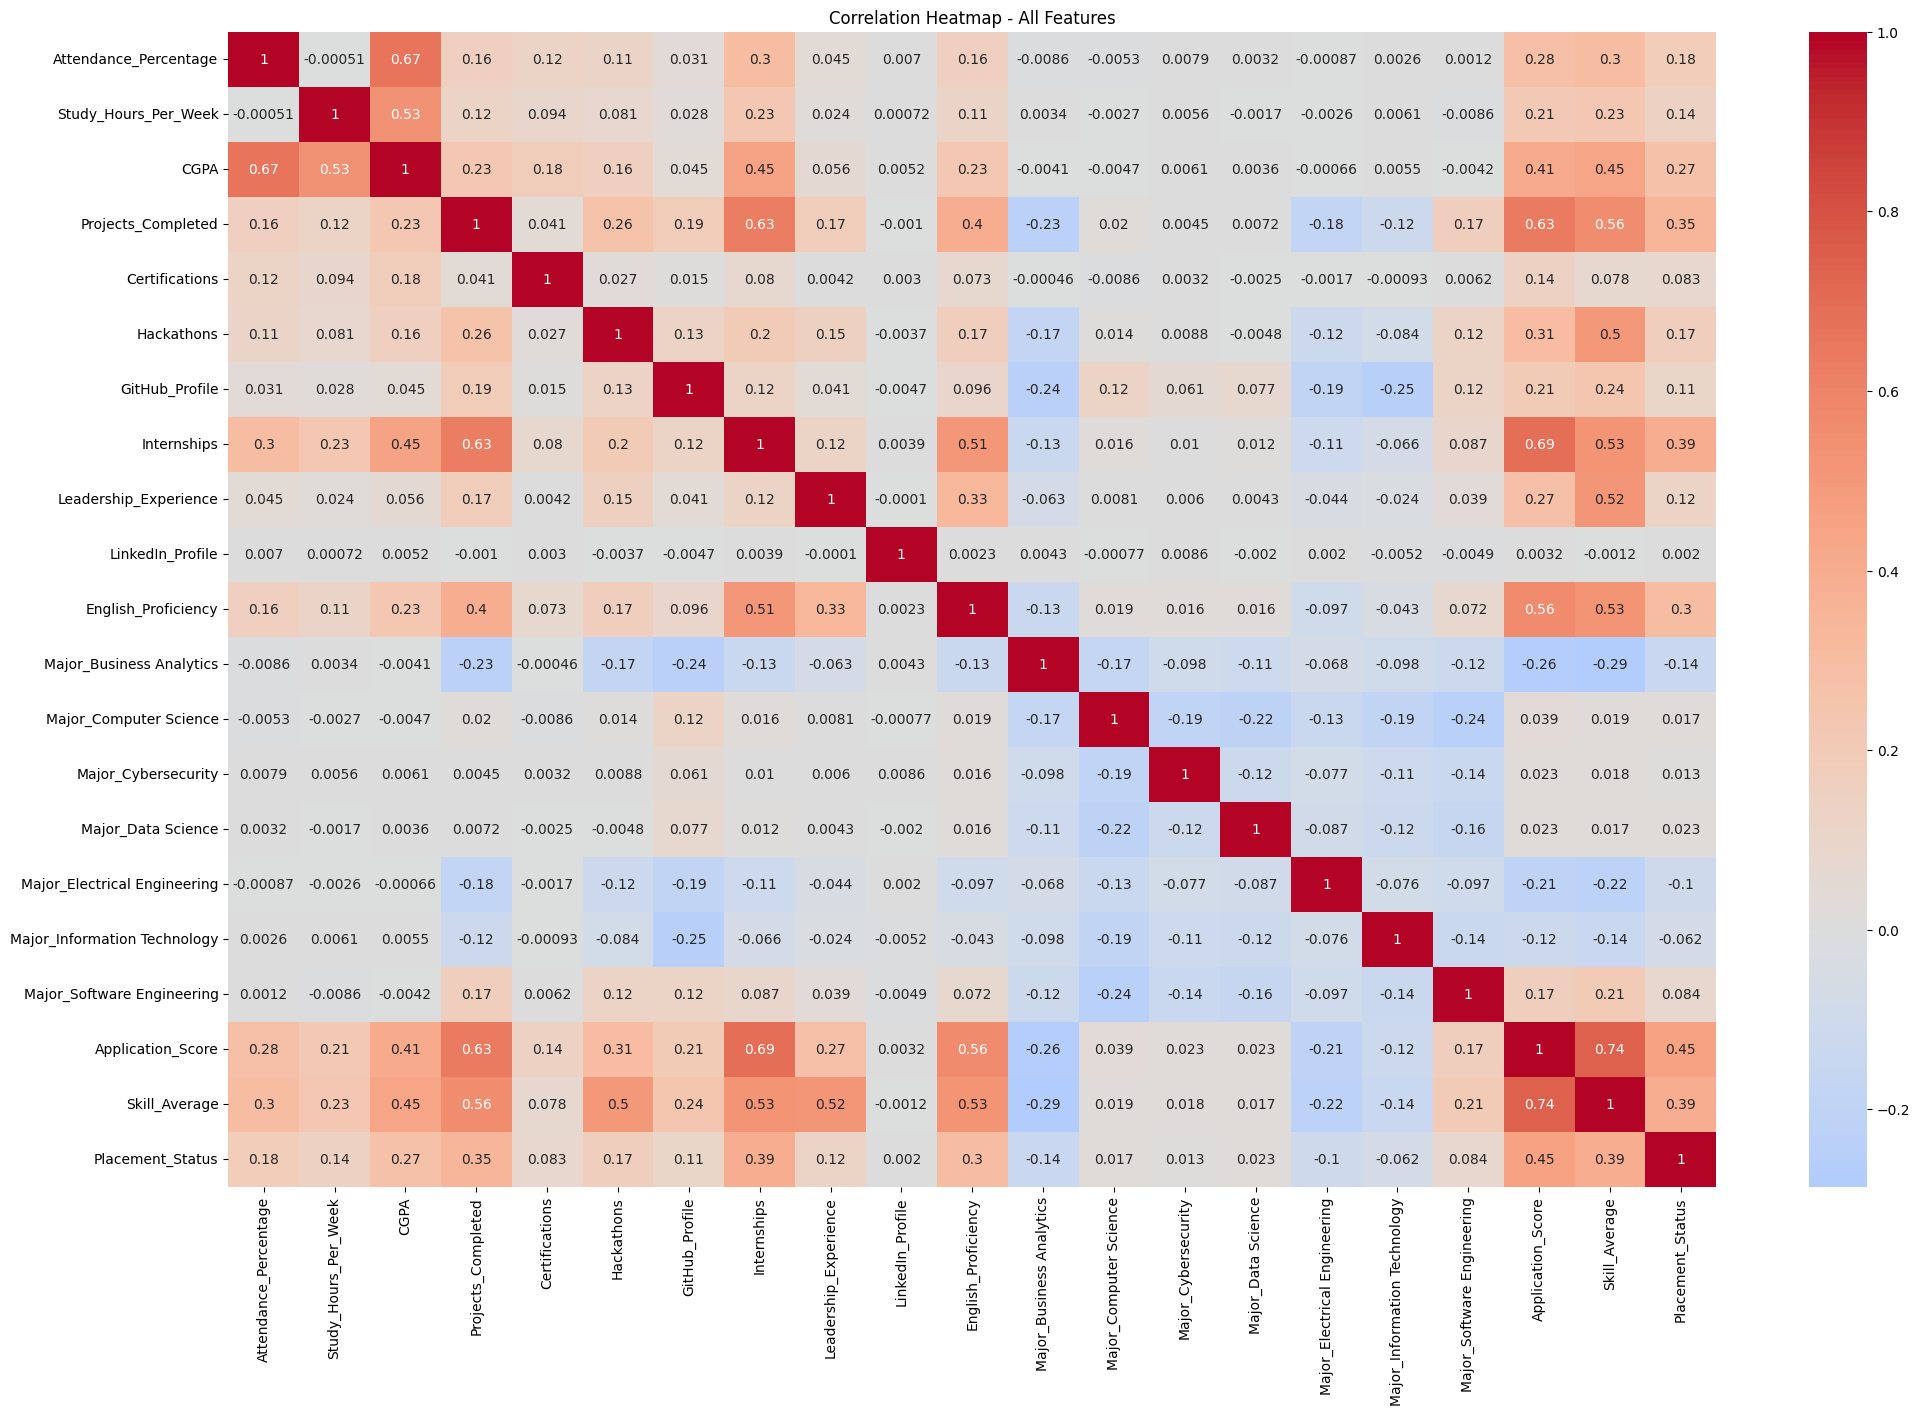

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ندمج X_train مع y_train مؤقتًا للرسم بس (من غير ما نعدل الأصل)
train_full = X_train.copy()
train_full['Placement_Status'] = y_train

# نحسب الـ correlation matrix
corr = train_full.corr()

plt.figure(figsize=(24, 15))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - All Features')
plt.show()

In [ ]:
X_train.describe()

,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Projects_Completed,Certifications,Hackathons,GitHub_Profile,Internships,Leadership_Experience,LinkedIn_Profile,English_Proficiency,Major_Business Analytics,Major_Computer Science,Major_Cybersecurity,Major_Data Science,Major_Electrical Engineering,Major_Information Technology,Major_Software Engineering,Application_Score,Skill_Average
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.00000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.00000,40000.000000,40000.000000,40000.000000,40000.000000
mean,81.439800,21.540450,3.106530,8.626125,1.708650,3.103500,0.813475,4.04870,0.391650,0.718300,1.781175,0.080500,0.248050,0.099525,0.123300,0.05075,0.098325,0.149950,86.800400,7.441975
std,9.703022,6.976853,0.290696,2.498729,1.367374,1.661944,0.389535,1.00576,0.488125,0.449833,0.442827,0.272069,0.431886,0.299369,0.328785,0.21949,0.297757,0.357027,9.047658,1.117421
min,50.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,35.500000,3.000000
25%,75.000000,17.000000,2.910000,7.000000,1.000000,2.000000,1.000000,3.00000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,82.500000,6.750000
50%,82.000000,22.000000,3.110000,9.000000,2.000000,3.000000,1.000000,4.00000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,88.500000,7.500000
75%,88.000000,26.000000,3.310000,10.000000,3.000000,4.000000,1.000000,5.00000,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,93.000000,8.250000
max,100.000000,45.000000,4.000000,15.000000,8.000000,10.000000,1.000000,5.00000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,100.000000,10.000000


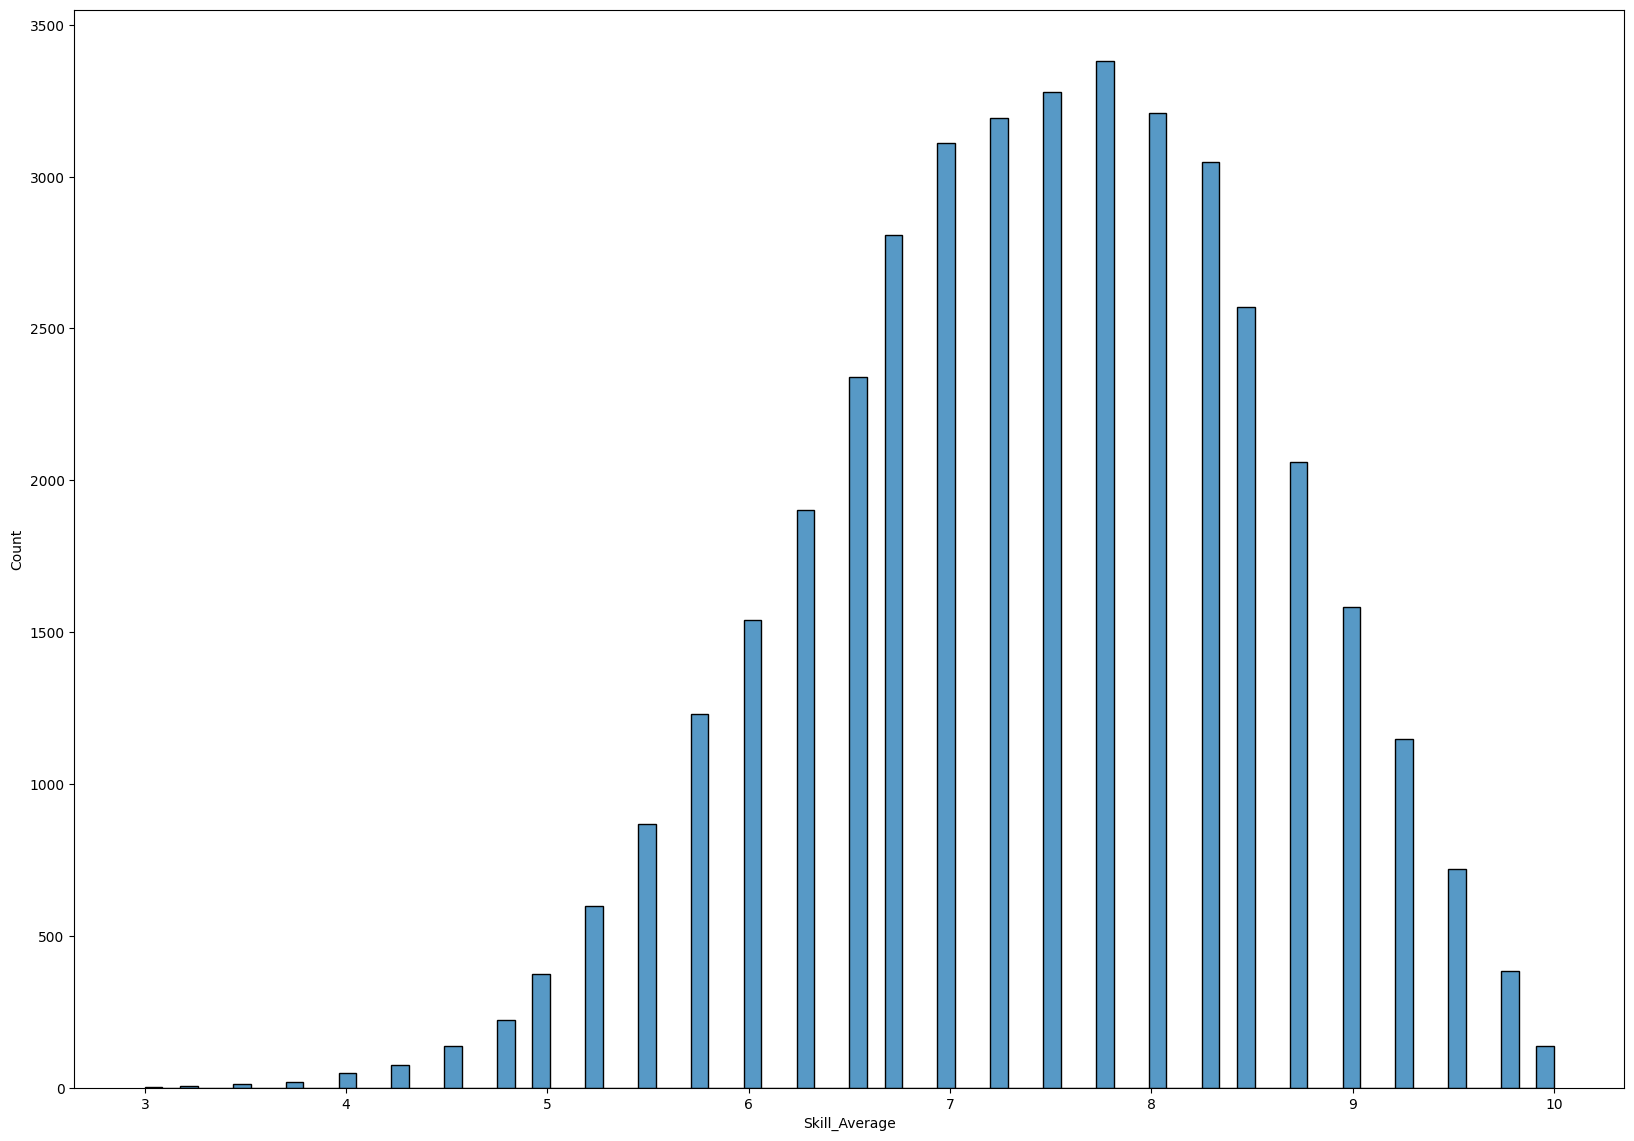

In [ ]:
plt.figure(figsize=(20,14))
sns.histplot(X_train['Skill_Average'])
plt.show()

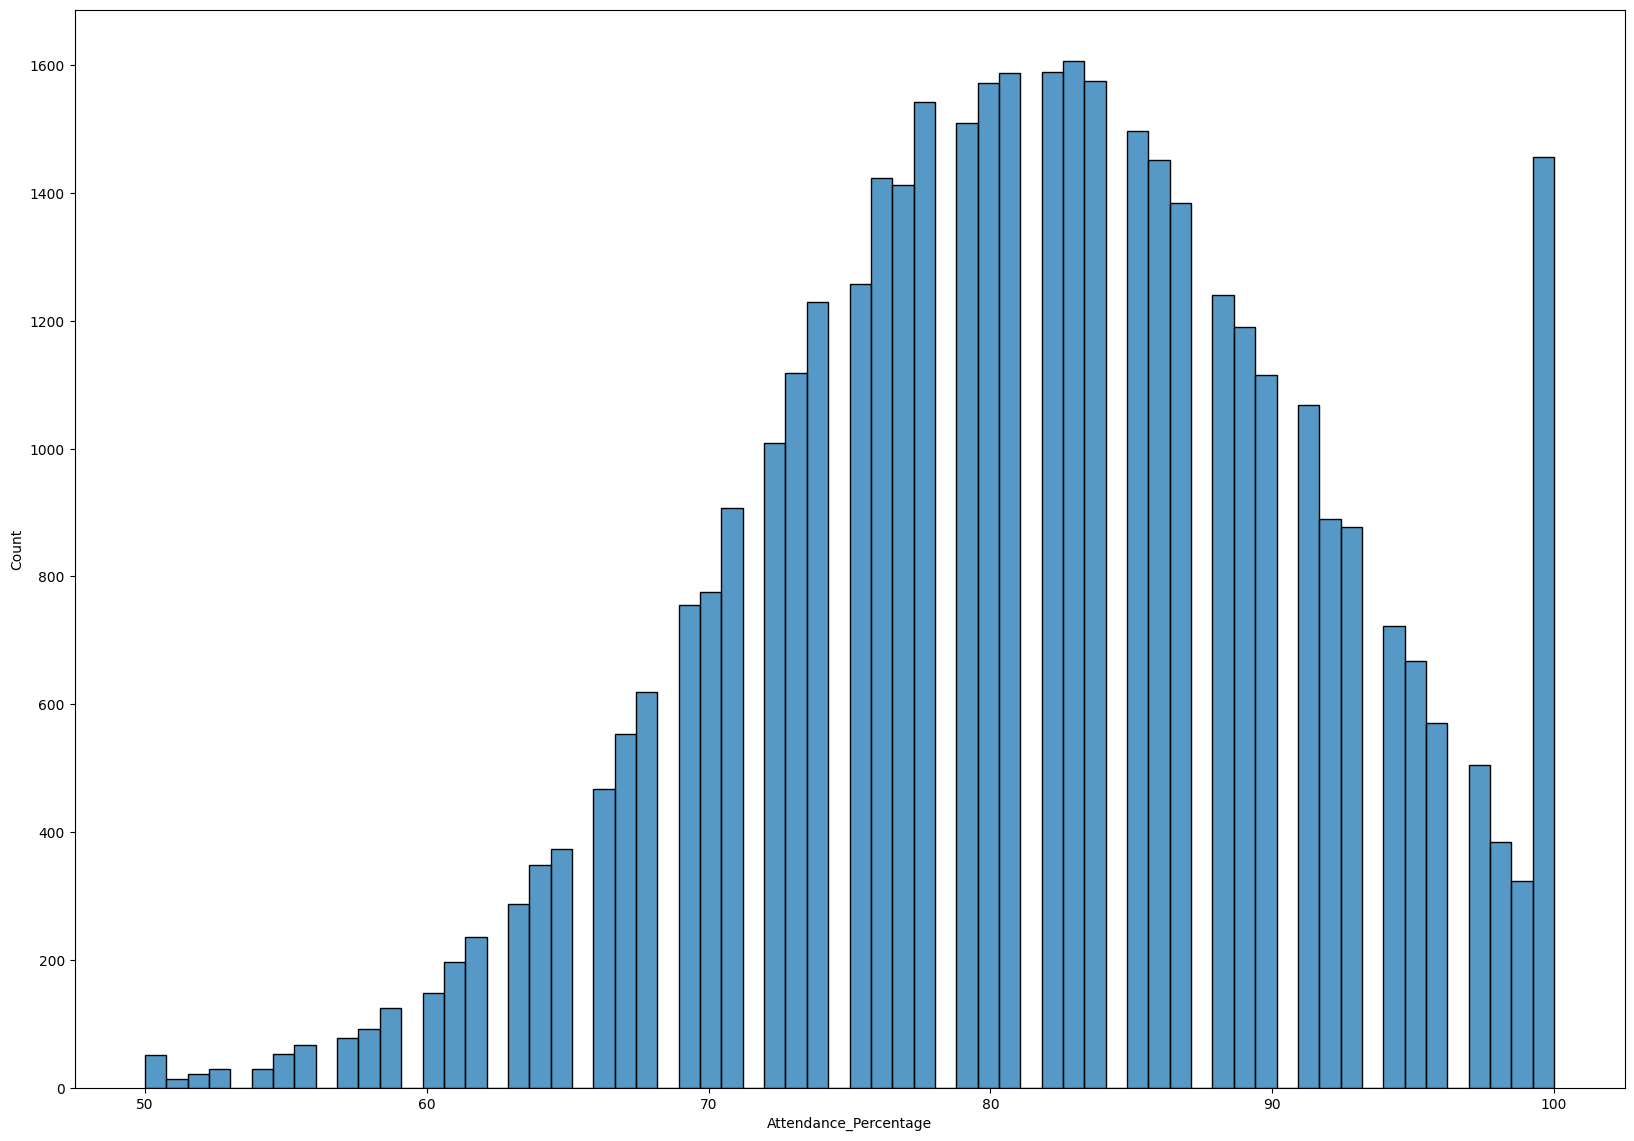

In [ ]:
plt.figure(figsize=(20,14))
sns.histplot(X_train['Attendance_Percentage'])
plt.show()    #transformation

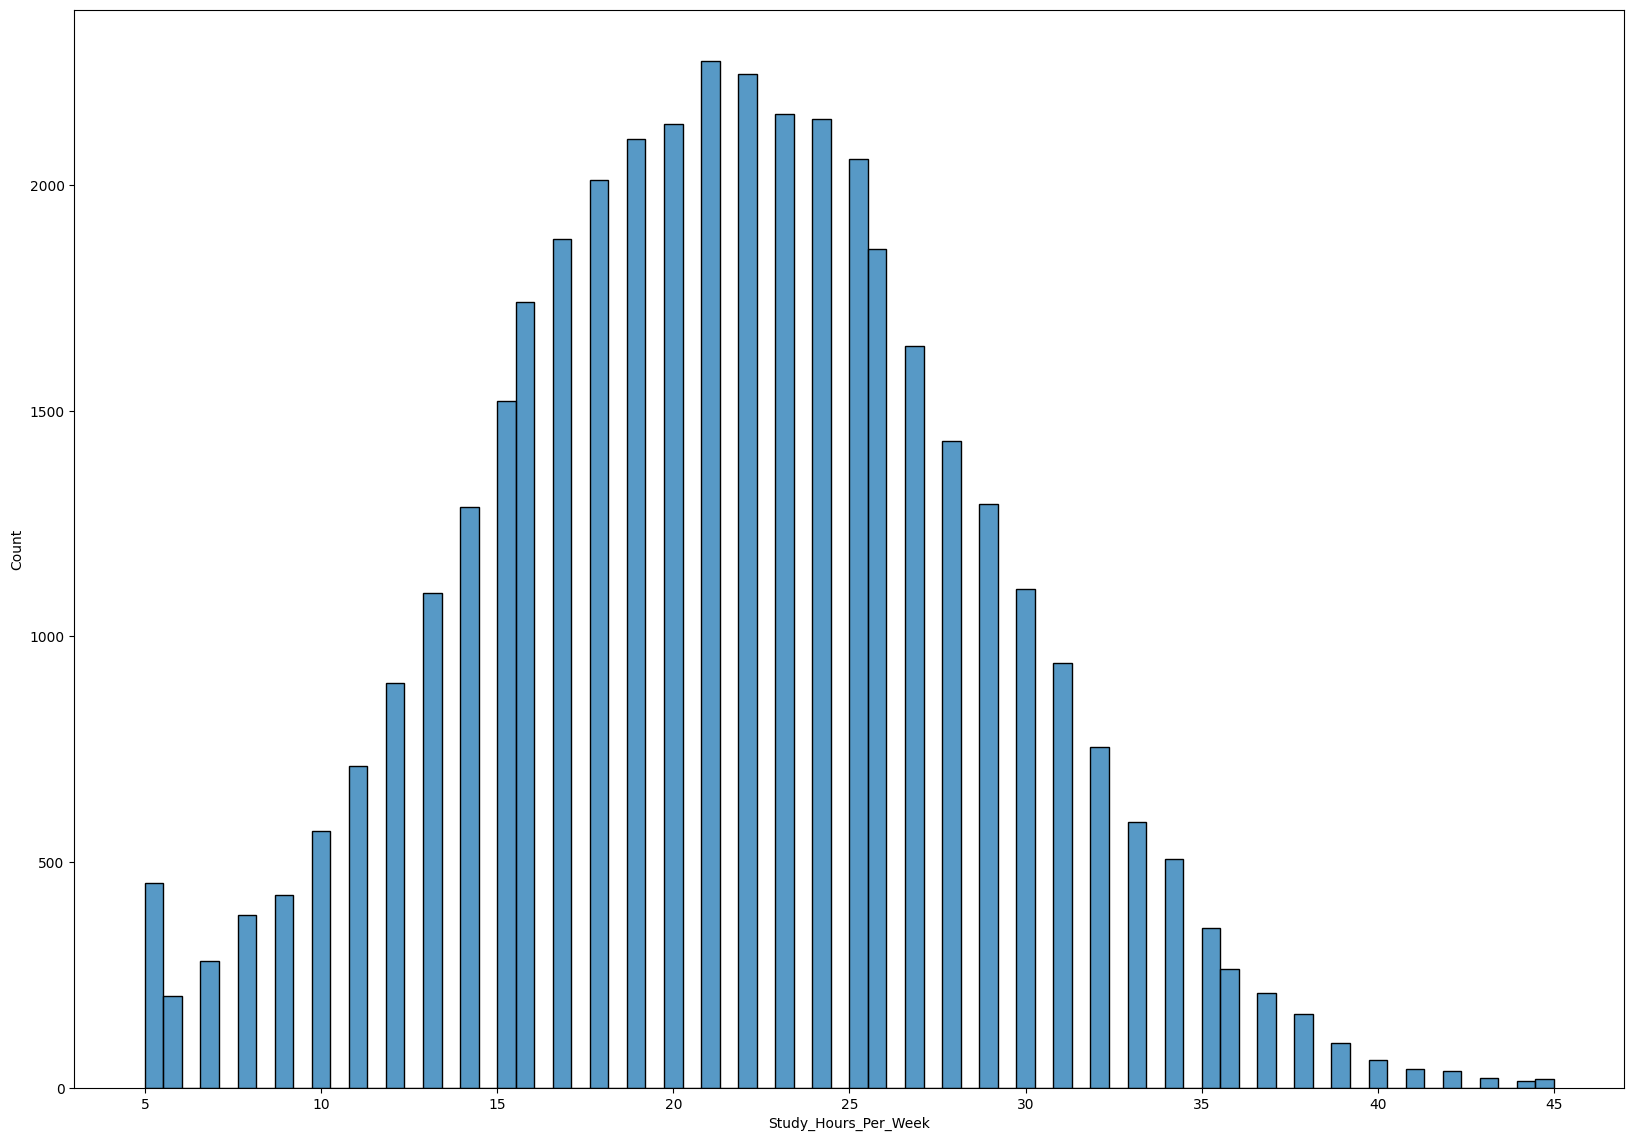

In [ ]:
plt.figure(figsize=(20,14))
sns.histplot(X_train['Study_Hours_Per_Week'])
plt.show()

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

#--DataFrame--
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


In [ ]:
X_train_scaled.describe()

,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Projects_Completed,Certifications,Hackathons,GitHub_Profile,Internships,Leadership_Experience,LinkedIn_Profile,English_Proficiency,Major_Business Analytics,Major_Computer Science,Major_Cybersecurity,Major_Data Science,Major_Electrical Engineering,Major_Information Technology,Major_Software Engineering,Application_Score,Skill_Average
count,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04
mean,-5.435652e-16,2.025047e-17,-2.100364e-15,-2.540190e-17,-1.723066e-17,5.595524e-17,1.071143e-16,-1.783462e-16,-1.953993e-18,-5.808687e-17,1.456613e-16,-6.457057e-17,4.369838e-17,1.563194e-17,-3.126388e-17,-1.196376e-16,5.329071e-18,-6.945555e-17,4.206413e-16,-2.035261e-16
std,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00
min,-3.240248e+00,-2.370790e+00,-3.806525e+00,-3.452248e+00,-1.249601e+00,-1.867415e+00,-2.088351e+00,-4.025563e+00,-8.023656e-01,-1.596833e+00,-4.022334e+00,-2.958844e-01,-5.743480e-01,-3.324530e-01,-3.750214e-01,-2.312212e-01,-3.302227e-01,-4.200017e-01,-5.670091e+00,-3.975252e+00
25%,-6.636985e-01,-6.507958e-01,-6.760727e-01,-6.507889e-01,-5.182626e-01,-6.639899e-01,4.788466e-01,-1.042707e+00,-8.023656e-01,-1.596833e+00,4.941611e-01,-2.958844e-01,-5.743480e-01,-3.324530e-01,-3.750214e-01,-2.312212e-01,-3.302227e-01,-4.200017e-01,-4.753113e-01,-6.192685e-01
50%,5.773531e-02,6.586863e-02,1.193872e-02,1.496279e-01,2.130753e-01,-6.227726e-02,4.788466e-01,-4.842169e-02,-8.023656e-01,6.262395e-01,4.941611e-01,-2.958844e-01,-5.743480e-01,-3.324530e-01,-3.750214e-01,-2.312212e-01,-3.302227e-01,-4.200017e-01,1.878521e-01,5.192825e-02
75%,6.761071e-01,6.392002e-01,6.999501e-01,5.498363e-01,9.444132e-01,5.394354e-01,4.788466e-01,9.458635e-01,1.246315e+00,6.262395e-01,4.941611e-01,-2.958844e-01,-5.743480e-01,-3.324530e-01,-3.750214e-01,-2.312212e-01,-3.302227e-01,-4.200017e-01,6.852245e-01,7.231250e-01
max,1.912851e+00,3.362525e+00,3.073590e+00,2.550878e+00,4.601103e+00,4.149711e+00,4.788466e-01,9.458635e-01,1.246315e+00,6.262395e-01,4.941611e-01,3.379698e+00,1.741105e+00,3.007944e+00,2.666515e+00,4.324862e+00,3.028259e+00,2.380943e+00,1.458915e+00,2.289251e+00


In [ ]:
Y_train.value_counts()  #impalanced

,count
Placement_Status,
Placed,31232
Not Placed,8768


In [ ]:
from imblearn.combine import SMOTETomek
from collections import Counter

print("Before SMOTETomek:", Counter(y_train))

smt = SMOTETomek(random_state=42)
X_train_res, Y_train_res = smt.fit_resample(X_train_scaled, y_train)

print("After SMOTETomek:", Counter(Y_train_res))

Before SMOTETomek: Counter({1: 31232, 0: 8768})
After SMOTETomek: Counter({0: 30963, 1: 30963})


##  ان شاء الله

KNN

In [ ]:
knn_9 = KNeighborsClassifier(n_neighbors=9)
knn_9.fit(X_train_res, Y_train_res)

KNeighborsClassifier(n_neighbors=9)

In [ ]:
Y_pred_knn_9 = knn_9.predict(X_test_scaled)

In [ ]:
print("Train Accuracy:", knn_9.score(X_train_scaled,Y_train))
print("Test Accuracy:", knn_9.score(X_test_scaled,Y_test))

Train Accuracy: 0.75555
Test Accuracy: 0.6766


In [ ]:
print(classification_report(Y_test, Y_pred_knn_9))

              precision    recall  f1-score   support

  Not Placed       0.37      0.71      0.49      2192
      Placed       0.89      0.67      0.76      7808

    accuracy                           0.68     10000
   macro avg       0.63      0.69      0.63     10000
weighted avg       0.78      0.68      0.70     10000



In [ ]:
print(confusion_matrix(Y_test, Y_pred_knn_9))

[[1547  645]
 [2589 5219]]


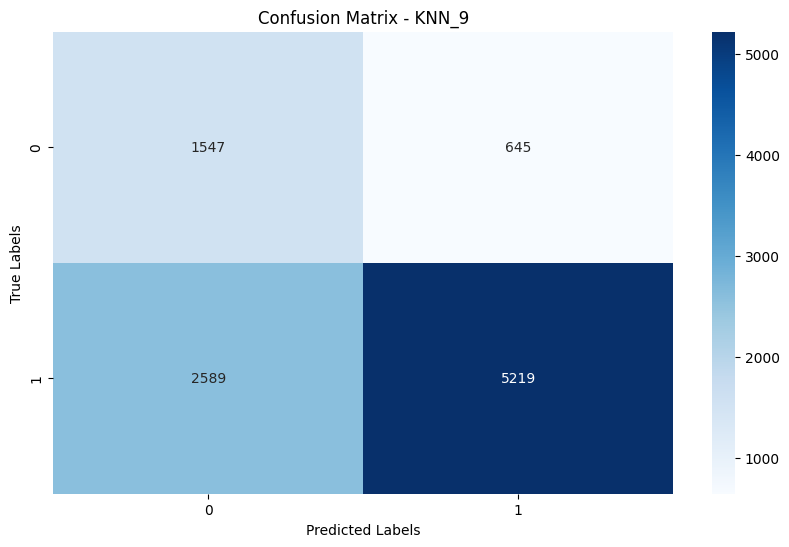

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(Y_test, Y_pred_knn_9), annot=True, cmap='Blues', fmt='d')
plt.title('Confusion Matrix - KNN_9')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
knn_5 = KNeighborsClassifier(n_neighbors=33)
knn_5.fit(X_train_res, Y_train_res)

KNeighborsClassifier(n_neighbors=33)

In [ ]:
Y_pred_knn_5 = knn_5.predict(X_test_scaled)

In [ ]:
print("Train Accuracy:", knn_5.score(X_train_scaled,Y_train))
print("Test Accuracy:", knn_5.score(X_test_scaled,Y_test))

Train Accuracy: 0.716525
Test Accuracy: 0.6881


In [ ]:
print(classification_report(Y_test, Y_pred_knn_5))

              precision    recall  f1-score   support

  Not Placed       0.39      0.75      0.51      2192
      Placed       0.91      0.67      0.77      7808

    accuracy                           0.69     10000
   macro avg       0.65      0.71      0.64     10000
weighted avg       0.79      0.69      0.71     10000



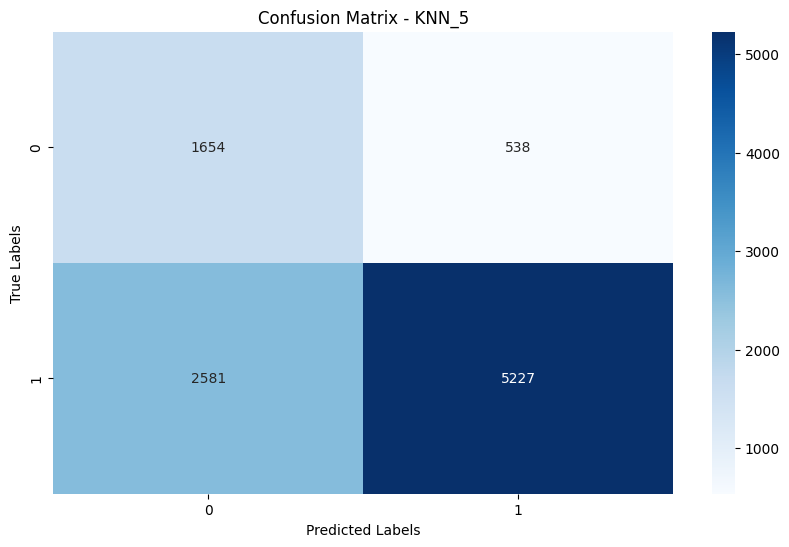

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(Y_test, Y_pred_knn_5), annot=True, cmap='Blues', fmt='d')
plt.title('Confusion Matrix - KNN_5')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Logistic regression

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']   # liblinear بيدعم l1 و l2 مع بعض
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(X_train_res, Y_train_res)

print("Best Params:", grid_lr.best_params_)
print("Best CV F1-Score:", grid_lr.best_score_)

best_lr = grid_lr.best_estimator_
Y_pred_lr = best_lr.predict(X_test_scaled)

print("Train Accuracy:", best_lr.score(X_train_scaled, y_train))
print("Test Accuracy:", best_lr.score(X_test_scaled, y_test))
print(classification_report(y_test, Y_pred_lr))

Best Params: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1-Score: 0.7479804904909557
Train Accuracy: 0.751
Test Accuracy: 0.7466
              precision    recall  f1-score   support

           0       0.45      0.71      0.55      2192
           1       0.90      0.76      0.82      7808

    accuracy                           0.75     10000
   macro avg       0.68      0.73      0.69     10000
weighted avg       0.80      0.75      0.76     10000



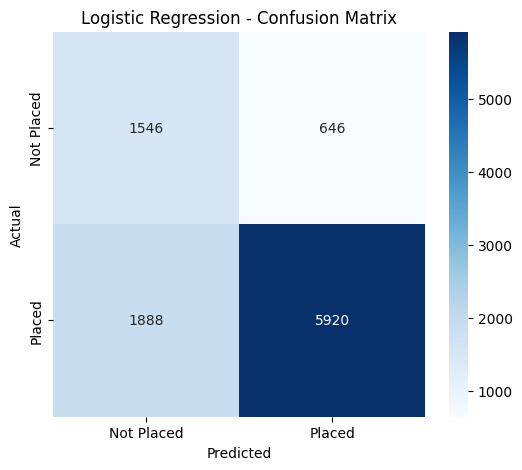

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test,Y_pred_lr),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Placed', 'Placed'],
            yticklabels=['Not Placed', 'Placed'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}
random_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_xgb.fit(X_train_res, Y_train_res)   # فاكر: y صغيرة = النسخة الرقمية

print("Best Params:", random_xgb.best_params_)
print("Best CV F1-Score:", random_xgb.best_score_)

best_xgb = random_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_scaled)

print("Train Accuracy:", best_xgb.score(X_train_scaled, y_train))
print("Test Accuracy:", best_xgb.score(X_test_scaled, y_test))
print(classification_report(y_test, y_pred_xgb))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV F1-Score: 0.8637240796415632
Train Accuracy: 0.875825
Test Accuracy: 0.8096
              precision    recall  f1-score   support

           0       0.60      0.38      0.47      2192
           1       0.84      0.93      0.88      7808

    accuracy                           0.81     10000
   macro avg       0.72      0.65      0.67     10000
weighted avg       0.79      0.81      0.79     10000



In [ ]:
grid_lr = LogisticRegression( max_iter=1000,random_state=42)
grid_lr.fit(X_train_res, Y_train_res)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
Y_pred_log = grid_lr.predict(X_test_scaled)

In [ ]:
print("Train Accuracy:", grid_lr.score(X_train_scaled,Y_train))
print("Test Accuracy:", grid_lr.score(X_test_scaled,Y_test))

Train Accuracy: 0.75095
Test Accuracy: 0.7465


In [ ]:
print(classification_report(Y_test, Y_pred_log, target_names=['Not Placed', 'Placed']))


              precision    recall  f1-score   support

  Not Placed       0.45      0.71      0.55      2192
      Placed       0.90      0.76      0.82      7808

    accuracy                           0.75     10000
   macro avg       0.68      0.73      0.69     10000
weighted avg       0.80      0.75      0.76     10000



# DecisionTree+RandomForest

In [ ]:
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=9, random_state=42)
clf_gini.fit(X_train_res,Y_train_res)

DecisionTreeClassifier(max_depth=9, random_state=42)

In [ ]:
Y_pred_gini = clf_gini.predict(X_test_scaled)

In [ ]:
print("Train Accuracy:", clf_gini.score(X_train_scaled,Y_train))
print("Test Accuracy:", clf_gini.score(X_test_scaled,Y_test))

Train Accuracy: 0.787975
Test Accuracy: 0.7772


In [ ]:
print(classification_report(Y_test, Y_pred_gini, target_names=['Not Placed', 'Placed']))

              precision    recall  f1-score   support

  Not Placed       0.49      0.55      0.52      2192
      Placed       0.87      0.84      0.86      7808

    accuracy                           0.78     10000
   macro avg       0.68      0.69      0.69     10000
weighted avg       0.79      0.78      0.78     10000



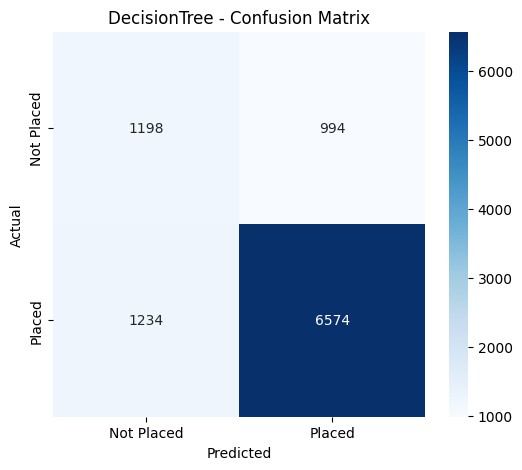

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(Y_test, Y_pred_gini),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Placed', 'Placed'],
            yticklabels=['Not Placed', 'Placed'])
plt.title('DecisionTree - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
rf_model = RandomForestClassifier(n_estimators=110,random_state=42)
rf_model.fit(X_train_res,Y_train_res)

RandomForestClassifier(n_estimators=110, random_state=42)

In [ ]:
Y_pred_rf = rf_model.predict(X_test_scaled)

In [ ]:
print("Train Accuracy:", rf_model.score(X_train_scaled,Y_train))
print("Test Accuracy:", rf_model.score(X_test_scaled,Y_test))

Train Accuracy: 0.995525
Test Accuracy: 0.8016


In [ ]:
print(classification_report(Y_test, Y_pred_rf, target_names=['Not Placed', 'Placed']))

              precision    recall  f1-score   support

  Not Placed       0.56      0.46      0.50      2192
      Placed       0.86      0.90      0.88      7808

    accuracy                           0.80     10000
   macro avg       0.71      0.68      0.69     10000
weighted avg       0.79      0.80      0.79     10000



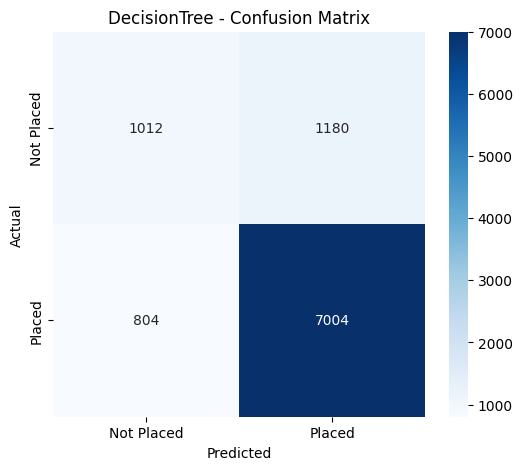

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(Y_test, Y_pred_rf),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Placed', 'Placed'],
            yticklabels=['Not Placed', 'Placed'])
plt.title('DecisionTree - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
rf_model1 = RandomForestClassifier(n_estimators=200, max_depth=9, min_samples_leaf=5, random_state=42)
rf_model1.fit(X_train_res,Y_train_res)

RandomForestClassifier(max_depth=9, min_samples_leaf=5, n_estimators=200,
                       random_state=42)

In [ ]:
Y_pred_rf1 = rf_model1.predict(X_test_scaled)

In [ ]:
print("Train Accuracy:", rf_model1.score(X_train_scaled,Y_train))
print("Test Accuracy:", rf_model1.score(X_test_scaled,Y_test))

Train Accuracy: 0.789175
Test Accuracy: 0.7721


In [ ]:
print(classification_report(Y_test, Y_pred_rf1, target_names=['Not Placed', 'Placed']))

              precision    recall  f1-score   support

  Not Placed       0.48      0.64      0.55      2192
      Placed       0.89      0.81      0.85      7808

    accuracy                           0.77     10000
   macro avg       0.69      0.72      0.70     10000
weighted avg       0.80      0.77      0.78     10000



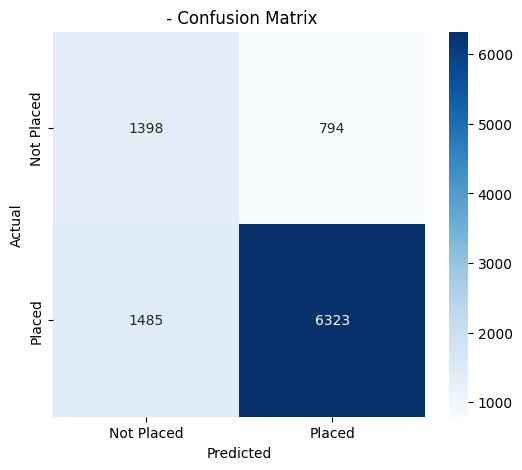

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(Y_test, Y_pred_rf1),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Placed', 'Placed'],
            yticklabels=['Not Placed', 'Placed'])
plt.title(' - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# boosting

In [ ]:
# AdaBoost
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train_res, Y_train_res)
Y_pred_ada = ada.predict(X_test_scaled)
print("AdaBoost - Train:", ada.score(X_train_scaled, Y_train))
print("AdaBoost - Test:", ada.score(X_test_scaled, Y_test))
print(classification_report(Y_test, Y_pred_ada))

AdaBoost - Train: 0.76505
AdaBoost - Test: 0.7556
              precision    recall  f1-score   support

  Not Placed       0.46      0.65      0.54      2192
      Placed       0.89      0.78      0.83      7808

    accuracy                           0.76     10000
   macro avg       0.67      0.72      0.69     10000
weighted avg       0.80      0.76      0.77     10000



In [ ]:
# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_res, Y_train_res)
Y_pred_gb = gb.predict(X_test_scaled)
print("Gradient Boosting - Train:", gb.score(X_train_scaled, Y_train))
print("Gradient Boosting - Test:", gb.score(X_test_scaled, Y_test))
print(classification_report(Y_test, Y_pred_gb))

Gradient Boosting - Train: 0.80875
Gradient Boosting - Test: 0.8038
              precision    recall  f1-score   support

  Not Placed       0.56      0.49      0.52      2192
      Placed       0.86      0.89      0.88      7808

    accuracy                           0.80     10000
   macro avg       0.71      0.69      0.70     10000
weighted avg       0.80      0.80      0.80     10000



In [ ]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.01,
    max_depth=7,
    random_state=42
)

# Train
Y_train_res_numeric = Y_train_res.map({'Placed': 1, 'Not Placed': 0})
model.fit(X_train_res, Y_train_res_numeric)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluation
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.59      0.54      2192
           1       0.88      0.84      0.86      7808

    accuracy                           0.78     10000
   macro avg       0.69      0.71      0.70     10000
weighted avg       0.80      0.78      0.79     10000



# SVM


In [ ]:
#instantiate classifier with rbf kernel and C=100
#svc=SVC(C=100.0)

# fit classifier to training set
#svc.fit(X_train_res,Y_train_res)

# make predictions on test set
#y_pred=svc.predict(X_test_scaled)

# compute and print accuracy score
#print('Model accuracy score with rbf kernel and C=100.0 : {0:0.4f}'. format(accuracy_score(Y_test, y_pred)))

In [ ]:
# instantiate classifier with linear kernel and C=1.0
#linear_svc=SVC(kernel='linear', C=1.0)

# fit classifier to training set
#linear_svc.fit(X_trian_res,Y_train_res)


# make predictions on test set
#y_pred_test=linear_svc.predict(X_test_scaled)


# compute and print accuracy score
#print('Model accuracy score with linear kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(Y_test, y_pred_test)))

In [ ]:
# instantiate classifier with polynomial kernel and C=1.0
#poly_svc=SVC(kernel='poly', C=1.0)


# fit classifier to training set
#poly_svc.fit(X_train_res,Y_train_res)


# make predictions on test set
#y_pred=poly_svc.predict(X_test_scaled)


# compute and print accuracy score
#print('Model accuracy score with polynomial kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(Y_test, Y_pred)))

In [ ]:
# instantiate classifier with sigmoid kernel and C=1.0
#sigmoid_svc=SVC(kernel='sigmoid', C=1.0)


# fit classifier to training set
#sigmoid_svc.fit(X_train,y_train)


# make predictions on test set
#y_pred=sigmoid_svc.predict(X_test)


# compute and print accuracy score
#print('Model accuracy score with sigmoid kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))